<a href="https://colab.research.google.com/github/Ayabergh/Dalaya-Ecommerce/blob/main/SentimentAnalysisDataset_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
import nltk
from nltk.tokenize import word_tokenize
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout,LSTM,GRU
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping



In [ ]:
'''

splits = {'train': 'train_df.csv', 'validation': 'val_df.csv', 'test': 'test_df.csv'}
df = pd.read_csv("hf://datasets/Sp1786/multiclass-sentiment-analysis-dataset/" + splits["train"])
'''

'\n\nsplits = {\'train\': \'train_df.csv\', \'validation\': \'val_df.csv\', \'test\': \'test_df.csv\'}\ndf = pd.read_csv("hf://datasets/Sp1786/multiclass-sentiment-analysis-dataset/" + splits["train"])\n'

### data explotation

In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "sentiment_data.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "abdelmalekeladjelet/sentiment-analysis-dataset",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_1908/2490920701.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 22.8M/22.8M [00:00<00:00, 29.6MB/s]


First 5 records:    Unnamed: 0                                            Comment  Sentiment
0           0  lets forget apple pay required brand new iphon...          1
1           1  nz retailers don’t even contactless credit car...          0
2           2  forever acknowledge channel help lessons ideas...          2
3           3  whenever go place doesn’t take apple pay doesn...          0
4           4  apple pay convenient secure easy use used kore...          2


In [ ]:
n_per_class = 13333

df_40k = (
    df.groupby('Sentiment', group_keys=False)
      .apply(lambda x: x.sample(n=n_per_class, random_state=42))
      .reset_index(drop=True)
)

print(df_40k['Sentiment'].value_counts())

Sentiment
0    13333
1    13333
2    13333
Name: count, dtype: int64


/tmp/ipykernel_1908/113890937.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=n_per_class, random_state=42))


In [ ]:
df=df_40k

In [ ]:
df.head()

,Unnamed: 0,Comment,Sentiment
0,50826,safeway bathroom still smells like ass,0
1,8005,calling someone “racist” “phobic” evidence bac...,0
2,10308,roast anybody without making feel bad,0
3,144702,plz send shah pakistan modi destroy economy th...,0
4,109841,recent survey teamlease services showed millio...,0


In [ ]:
df['Sentiment'].unique()

array([0, 1, 2])

In [ ]:
df.shape

(39999, 3)

In [ ]:
df.describe()

,Unnamed: 0,Sentiment
count,39999.000000,39999.000000
mean,120741.635391,1.000000
std,69340.596586,0.816507
min,31.000000,0.000000
25%,60721.500000,0.000000
50%,119917.000000,1.000000
75%,180724.000000,2.000000
max,241916.000000,2.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39999 entries, 0 to 39998
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  39999 non-null  int64 
 1   Comment     39969 non-null  object
 2   Sentiment   39999 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 937.6+ KB


### Exploration Data Analysis

In [ ]:
df.isna().sum()

,0
Unnamed: 0,0
Comment,30
Sentiment,0


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

empty texts

In [ ]:
(df['Comment'].str.strip()=='').sum()

np.int64(0)

text length

In [ ]:
df['text_len'] = df['Comment'].str.len()
df['text_len'].describe()

,text_len
count,39969.000000
mean,87.912933
std,75.598427
min,1.000000
25%,41.000000
50%,72.000000
75%,124.000000
max,5080.000000


In [ ]:
df.head()

,Unnamed: 0,Comment,Sentiment,text_len
0,50826,safeway bathroom still smells like ass,0,38
1,8005,calling someone “racist” “phobic” evidence bac...,0,68
2,10308,roast anybody without making feel bad,0,37
3,144702,plz send shah pakistan modi destroy economy th...,0,156
4,109841,recent survey teamlease services showed millio...,0,168


text len distribution

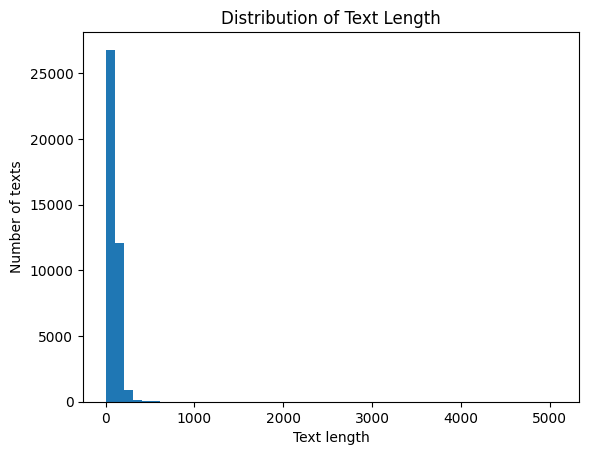

In [ ]:
import matplotlib.pyplot as plt
plt.hist(df['text_len'], bins=50)
plt.xlabel('Text length')
plt.ylabel('Number of texts')
plt.title('Distribution of Text Length')
plt.show()

short text

In [ ]:
short_text = df[df['text_len']<=3]

In [ ]:
print(short_text[['Comment', 'Sentiment']])
short_text.shape

      Comment  Sentiment
545       fun          0
665       day          0
3718      fan          0
5000      wtf          0
7790      yep          0
8489       oh          0
9326      sad          0
10220     sad          0
12436     bad          0
13578     may          1
13636     ari          1
13803       u          1
14001     way          1
14720     bjp          1
16168     yes          1
17877     sad          1
17920      ok          1
18613     say          1
18696     hes          1
19473     cat          1
19672      im          1
19757     new          1
19874     see          1
20002     len          1
20346     yes          1
20930     app          1
21353     yep          1
21433     thx          1
21661     ohh          1
22076     see          1
23563     saw          1
23628     see          1
23632     rus          1
24018     yes          1
24307     hey          1
25183      im          1
26589     ive          1
26667       💖          2
27714     yes          2


(45, 4)

In [ ]:
threshold = df['text_len'].quantile(0.99)
print('threshold:',threshold)
long_text = df[df['text_len']>threshold]
print(long_text[['Comment', 'Sentiment']])
long_text.shape

threshold: 263.0
                                                 Comment  Sentiment
99     concept good execution lacks constant issues s...          0
216    use mase sunday school teacher atlanta first g...          0
359    syncing doesnt work whole point upgrading pro ...          0
368    loved app recently realized dont use half much...          0
465    parents expect us school constant straight a’s...          0
...                                                  ...        ...
39258  business owner video enthusiast love channel d...          2
39321  computer science major soon working nyc softwa...          2
39419  got hyped especially hrithik highlight also fa...          2
39703  hey everyone wanted make video could easily te...          2
39798  havent come across better app type project man...          2

[397 rows x 2 columns]


(397, 4)

In [ ]:
df['Sentiment'].value_counts()

,count
Sentiment,
2,13333
0,13331
1,13305


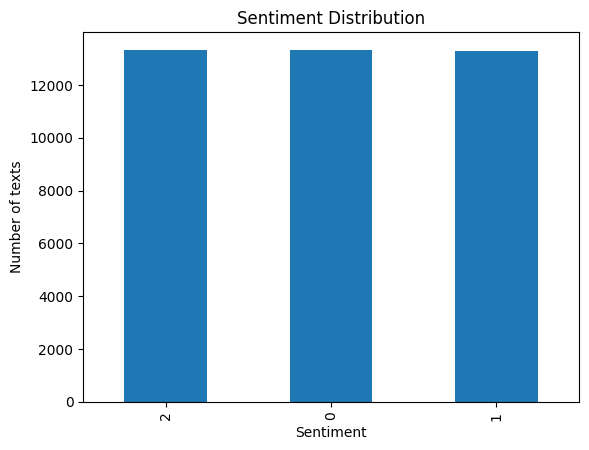

In [ ]:
df['Sentiment'].value_counts().plot(kind='bar')
plt.xlabel('Sentiment')
plt.ylabel('Number of texts')
plt.title('Sentiment Distribution')
plt.show()

In [ ]:
html_count=df['Comment'].str.contains(
      r'<[^>]+>',
    regex=True,
    na=False
).sum()
print("Texts containing HTML:", html_count)

Texts containing HTML: 0


In [ ]:
df['Comment']=df['Comment'].str.replace(
    r'<[^>]+>',
    '',
    regex=True
)

In [ ]:
url_count = df['Comment'].str.contains(
    r'https?://\S+|www\.\S+',
    regex=True,
    na=False
).sum()

print("Comments containing URLs:", url_count)

Comments containing URLs: 0


In [ ]:
df['Comment']=df['Comment'].str.replace(
    r'https?://\S+|www\.\S+',
    '',
    regex=True
)

In [ ]:
df['Comment']=df['Comment'].str.replace(
    r'\s+',
    ' ',
    regex=True
)

In [ ]:
df['Comment'].iloc[2]

'roast anybody without making feel bad'

In [ ]:
df.head()

,Unnamed: 0,Comment,Sentiment,text_len
0,50826,safeway bathroom still smells like ass,0,38
1,8005,calling someone “racist” “phobic” evidence bac...,0,68
2,10308,roast anybody without making feel bad,0,37
3,144702,plz send shah pakistan modi destroy economy th...,0,156
4,109841,recent survey teamlease services showed millio...,0,168


check emojis

In [ ]:
emojy_pattern = r'[^\x00-\x7f]'

emoji_texts = df[df['Comment'].str.contains(
    emojy_pattern,
    regex=True,
    na=False
)]
print(emoji_texts[['Comment', 'Sentiment']].head(20))
emoji_texts.shape

                                               Comment  Sentiment
1    calling someone “racist” “phobic” evidence bac...          0
4    recent survey teamlease services showed millio...          0
6    modiâ promise bring internet rural india fai...          0
14   want comment fake never issued signed statemen...          0
32   believe live modi hate minorities pluralism in...          0
33   destroying satellites mediaâ freedom express...          0
35   donâ serious talk rahul also get list top in...          0
47   even modi doesnâ win according stats italian...          0
52   âdelaying decisions criminal negligenceâ m...          0
56   donâ understand people afraid chest thumping...          0
63   would taken blame mission failure internationa...          0
65   india shoots satellite space modi salutes majo...          0
74   sheâ corrupt means modi sarkar fails take le...          0
83   nirav modi vijay mallya share jail cell mumbai...          0
95   lot t

(3958, 4)

In [ ]:

X= df['Comment']
y= df['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
# tokenizing the comments
tokenizer=Tokenizer(num_words=20000,oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

print(X_train_seq[:3])

[[490, 449, 89, 2, 554, 4438, 2354, 880, 90, 1459, 1460, 19, 252, 1755, 1041, 18109, 1651, 18110, 18111, 18112, 2564, 6623, 2091, 12678, 12679], [18113, 1288, 4, 18114, 550, 44, 32, 40, 945, 201, 2092, 32], [8483, 185, 18115, 1028, 5985, 18116, 1984, 80, 3956, 6624, 4711, 2822, 5, 110, 710, 57, 7422, 1430, 10071, 5986, 1933, 37, 1756, 2725, 322]]


In [ ]:
# sequencing the tokenized comments
max_lengh=100
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_lengh,
    padding='post',
    truncating='post'
)
X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_lengh,
    padding='post',
    truncating='post'
)
print(X_train_pad.shape)
print(X_test_pad.shape)

(31975, 100)
(7994, 100)


### training the model

build the NN model

In [ ]:
# le model RNN

model = Sequential([
    Embedding(
        input_dim=20000,
        output_dim=128,
        input_length=max_lengh,
        mask_zero=True

    ),
    LSTM(128),

    Dropout(0.3),

    Dense(64, activation='relu'),

    Dense(3, activation='softmax')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from sklearn.model_selection import train_test_split

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_pad,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    mode='min',
    restore_best_weights=True
)
history = model.fit(
    X_train_final,
    y_train_final,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=128,
    callbacks=[early_stop]
)

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 92s 441ms/step - accuracy: 0.6263 - loss: 0.8418 - val_accuracy: 0.7400 - val_loss: 0.6678
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 152s 492ms/step - accuracy: 0.8232 - loss: 0.4815 - val_accuracy: 0.7389 - val_loss: 0.6530
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 91s 456ms/step - accuracy: 0.8828 - loss: 0.3273 - val_accuracy: 0.7415 - val_loss: 0.7576
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 103s 518ms/step - accuracy: 0.9129 - loss: 0.2391 - val_accuracy: 0.7334 - val_loss: 0.9253


In [ ]:
best_val_accuracy = max(history.history['val_accuracy'])
best_epoch = history.history['val_accuracy'].index(best_val_accuracy) + 1

print(f"Meilleure val_accuracy : {best_val_accuracy:.4f} (epoch {best_epoch})")

Meilleure val_accuracy : 0.7415 (epoch 3)
